In [1]:
from pathlib import Path
from torchvision import models
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import pandas as pd
import json
import timm
from tqdm import tqdm
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore', module='ipykernel')

# Force tqdm to use simple display
from tqdm import tqdm
tqdm.monitor_interval = 0

# Alternative: Create a wrapper function for tqdm
def simple_tqdm(iterable, **kwargs):
    return tqdm(iterable, **kwargs, ascii=True, ncols=80)

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")

Using device: mps


In [4]:
SPLIT_DIR = Path.cwd().resolve() / "Data" / "splits"

In [5]:
# Load the datasets
train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

In [6]:
# Load the class mapping
with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

In [7]:
# Define transforms (fixing the syntax error from before)
train_tfms_mild = get_train_tfms_mild() 
train_tfms_strong = get_train_tfms_strong() 
val_tfms = get_val_tfms()

print("All files loaded successfully!")

All files loaded successfully!


In [8]:
save_dir = PROJECT_ROOT / "Graphs"
save_dir.mkdir(parents=True, exist_ok=True)

In [9]:
CLASSES = sorted(train["class"].unique().tolist())

In [10]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x3a10a3310>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x3a102c510>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x3a05e4190>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x3a06bb3d0>}

In [11]:
train_loader = loaders["train_loader_strong"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [12]:
criterion = nn.CrossEntropyLoss()

## Training and Validation

### Load RESNET50 Model

In [13]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

In [14]:
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [15]:
def run_one_epoch(model, loader, criterion, optimizer, device, scaler=None, is_train=False, return_preds=False):
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    # Start timer for the whole epoch
    start_time = time.time()
    
    if is_train:
        model.train()
    else:
        model.eval()
    
    num_batches = len(loader)
    
    for i, (img, labels) in enumerate(loader):
        img, labels = img.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            outputs = model(img)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                outputs = model(img)
                loss = criterion(outputs, labels)

        # Update metrics
        preds = outputs.argmax(1)
        batch_size = img.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        total += batch_size

        # --- PROGRESS PRINTING (The "is it running?" part) ---
        # Prints every 5 batches (adjust as needed for your dataset size)
        if (i + 1) % 5 == 0 or (i + 1) == num_batches:
            elapsed = time.time() - start_time
            print(f"  Batch {i+1}/{num_batches} | Loss: {loss.item():.4f} | "
                  f"Acc: {running_correct/total:.4f} | Time: {elapsed:.1f}s", end='\r')

        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    # Final epoch stats
    total_loss = running_loss / max(total, 1)
    total_acc = running_correct / max(total, 1)
    
    # Move to new line after carriage return
    print() 

    if return_preds:
        return total_loss, total_acc, total, torch.cat(all_labels), torch.cat(all_preds)
    else:
        return total_loss, total_acc, total, None, None

In [16]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet50_best.pth"

In [17]:
BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

In [18]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=3):
    best_val_acc = -float("inf")
    bad_epochs = 0
    total_start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f"\n>>> Epoch {epoch + 1}/{num_epochs} start")

        # Training phase
        train_loss, train_acc, _, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, device, is_train=True
        )
        
        # Validation phase
        val_loss, val_acc, _, _, _ = run_one_epoch(
            model, val_loader, criterion, optimizer, device, is_train=False
        )

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch + 1} Done | Time: {epoch_time:.1f}s")
        print(f"Stats: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f">>> New Best Val Acc: {val_acc:.4f}! Model Saved.")
        else:
            bad_epochs += 1
            print(f"--- No improvement. Patience: {bad_epochs}/{patience}")
            if bad_epochs >= patience:
                print("!!! Early stopping triggered.")
                break

    total_time = time.time() - total_start_time
    print(f"\n>>> Training Complete! Total Time: {total_time/60:.1f} minutes")
    
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    return model

In [19]:
train(model, train_loader, val_loader, criterion, optimizer, num_epochs=20, device=device, patience=5)


>>> Epoch 1/20 start
  Batch 151/151 | Loss: 0.4951 | Acc: 0.7698 | Time: 582.6s
  Batch 19/19 | Loss: 0.3386 | Acc: 0.8325 | Time: 28.0s
Epoch 1 Done | Time: 610.7s
Stats: train_loss=0.5450, train_acc=0.7698, val_loss=0.3955, val_acc=0.8325
>>> New Best Val Acc: 0.8325! Model Saved.

>>> Epoch 2/20 start
  Batch 151/151 | Loss: 0.3679 | Acc: 0.8422 | Time: 583.0s
  Batch 19/19 | Loss: 0.3090 | Acc: 0.8605 | Time: 28.0s
Epoch 2 Done | Time: 611.0s
Stats: train_loss=0.3836, train_acc=0.8422, val_loss=0.3627, val_acc=0.8605
>>> New Best Val Acc: 0.8605! Model Saved.

>>> Epoch 3/20 start
  Batch 151/151 | Loss: 0.3970 | Acc: 0.8657 | Time: 581.4s
  Batch 19/19 | Loss: 0.3202 | Acc: 0.8715 | Time: 28.4s
Epoch 3 Done | Time: 609.8s
Stats: train_loss=0.3269, train_acc=0.8657, val_loss=0.3179, val_acc=0.8715
>>> New Best Val Acc: 0.8715! Model Saved.

>>> Epoch 4/20 start
  Batch 151/151 | Loss: 0.3639 | Acc: 0.8838 | Time: 585.0s
  Batch 19/19 | Loss: 0.2987 | Acc: 0.8713 | Time: 28.7s
Epo

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [20]:
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)
state_dict = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Testing

In [21]:
test_loss, test_acc, test_total, test_labels, test_preds = run_one_epoch(
    model, test_loader, criterion, optimizer, device, is_train=False, return_preds=True
)

  Batch 19/19 | Loss: 0.4361 | Acc: 0.8806 | Time: 28.2s


In [22]:
print("Test accuracy:", test_acc)

Test accuracy: 0.8806310981938966


In [23]:
cm = confusion_matrix(test_labels, test_preds)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n",
    classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

Confusion matrix:
 [[1384  168   53]
 [  92 1423   91]
 [  66  105 1435]]

Classification report:
                       precision    recall  f1-score   support

conditionally_edible     0.8975    0.8623    0.8796      1605
              edible     0.8390    0.8861    0.8619      1606
               toxic     0.9088    0.8935    0.9011      1606

            accuracy                         0.8806      4817
           macro avg     0.8818    0.8806    0.8809      4817
        weighted avg     0.8818    0.8806    0.8809      4817



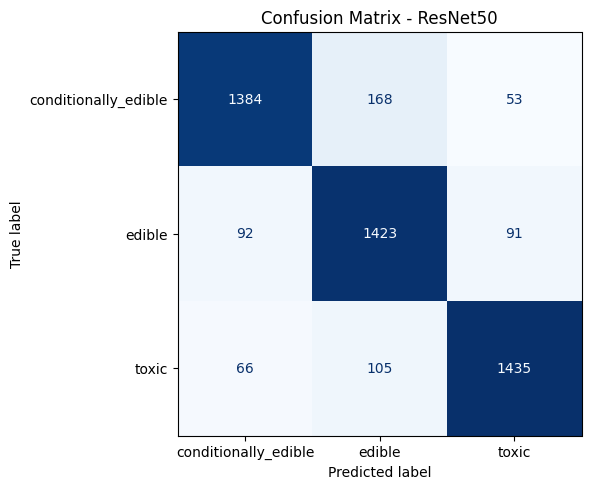

In [24]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix - ResNet50")
plt.tight_layout()

# 3. SAVE FIRST, THEN SHOW
plt.savefig(save_dir / "resnet50_confusion_matrix.png", dpi=300)
plt.show()